In [8]:
import os
import numpy as np
import torch
import csv
from torchvision.models import resnet50
from torchvision import transforms, utils
from PIL import Image
from scipy.signal import resample_poly
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #Remember to install the GPU version of Pytorch!!!!!!
print(f"Using device: {device}")

Using device: cuda


In [ ]:
model = resnet50(pretrained=True) #That would require you to download the pre-trained weights from the ResNet50 model's official page.
num_features = model.fc.in_features #Then place it in a target folder according to their instructions.
model.fc = nn.Linear(num_features, 1)

for param in model.parameters():
    param.requires_grad = False
    
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True


model.fc.requires_grad = True

In [ ]:
checkpoint = torch.load('C:\\Machine Learning-FRBs\\model_weights\\res50_weights\\fold_6\\best_mae.pth', map_location=device)
model.load_state_dict(checkpoint['state_dict'])
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [58]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

['wfall', 'params']


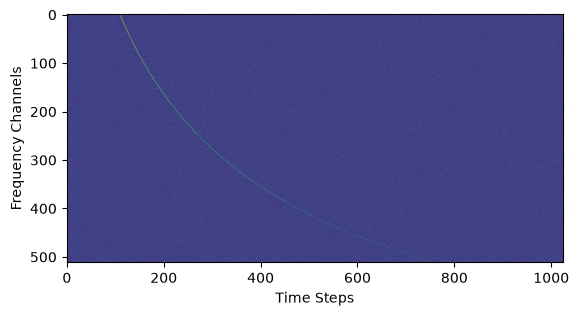

In [71]:
raw_data = np.load("C:\\Machine Learning-FRBs\\sample data\\wfall_27274.npz", allow_pickle=True)
print(raw_data.files)
frbs = raw_data['wfall']
frbs_norm = (frbs - np.min(frbs)) / (np.max(frbs) - np.min(frbs))
tensor_frb_norm = transform(Image.fromarray((frbs_norm * 255).astype(np.uint8))).unsqueeze(0).to(device)

plt.imshow(frbs)
plt.xlabel("Time Steps")
plt.ylabel("Frequency Channels")
plt.show()

In [72]:
print(tensor_frb_norm.shape)

torch.Size([1, 3, 224, 224])


In [73]:
with torch.no_grad():
    predicted_dm = model(tensor_frb_norm).item()

ground_truth_dm = raw_data['params'][0]

print(f'prediction: {predicted_dm}')
print(f'ground truth: {ground_truth_dm}')

prediction: 398.3096008300781
ground truth: 398.28656647750944
